# View Analysis — Wing Shapes, Attractor Views & Extensible Objectives

## Shape morphing

| Old (`optimize_shape=True` v1) | New (`optimize_shape=True` v2) |
|---|---|
| `scale(x=s, y=1/s)` — distorts all vertices | `building_depth` + `shape_ratio` + `end_rot_i` per leaf wing |
| Area preserved, but shape looks stretched | Area preserved, wing thickness preserved, character preserved |

Variables when `optimize_shape=True`:
```
building_depth  ∈ [5, 25]     — wing thickness (m)
shape_ratio     ∈ [0.05, 0.95] — how area splits between wings
end_rot_i       ∈ [-45, 45]   — one rotation variable per LEAF wing
```

## Extensible objectives

Pass any combination of registered objectives:
```python
from agent.tools.view_optimizer import OBJECTIVE_REGISTRY, list_objectives
# currently: unblocked_view, attractor_view, clearance_from_site,
#            clearance_from_obstacles, sky_exposure

objective_configs = [
    {"name": "unblocked_view",      "weight": 0.6},
    {"name": "attractor_view",       "weight": 0.3, "attractors": [...]},
    {"name": "clearance_from_site",  "weight": 0.1},
]
```
Adding a new objective = adding a function to `OBJECTIVE_REGISTRY` in `view_optimizer.py`.

In [1]:
import sys, os, math
sys.path.insert(0, os.path.abspath('..'))

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from shapely.geometry import Polygon
from shapely import affinity

from agent.tools.view_analysis import evaluate_building_views, evaluate_attractor_views
from agent.tools.parametric_shape import shape_variable_spec, apply_shape_variables
from agent.tools.view_optimizer import (
    OBJECTIVE_REGISTRY, list_objectives, evaluate_combined_score,
    sample_valid_placements, rank_placements_by_view,
    optimize_view_placement, optimize_two_building_placement,
)
from agent.tools.building_shape_graph import build_shape_model

print('Registered objectives:', list_objectives())

Registered objectives: ['attractor_view', 'clearance_from_obstacles', 'clearance_from_site', 'sky_exposure', 'unblocked_view']


## 1. Test Scene

In [2]:
site_boundary = [[0,0,0],[100,0,0],[100,100,0],[0,100,0],[0,0,0]]

# Building TYPES and target areas  (shapes generated parametrically)
BTYPE_1, AREA_1 = 'L', 675.0
BTYPE_2, AREA_2 = 'T', 600.0

# Default polygon templates (depth=15, ratio=0.5) used for seed-point step
def make_base_polygon(btype, area):
    return build_shape_model(area=area, building_type=btype,
                             building_depth=15.0, shape_ratio=0.5).polygon

base_poly_1 = make_base_polygon(BTYPE_1, AREA_1)
base_poly_2 = make_base_polygon(BTYPE_2, AREA_2)
bld_origin_1 = [[round(float(x),3), round(float(y),3), 0.0] for x,y in base_poly_1.exterior.coords]
bld_origin_2 = [[round(float(x),3), round(float(y),3), 0.0] for x,y in base_poly_2.exterior.coords]

# External obstacles (outside site)
external_obstacles = [
    [[108,15,0],[155,15,0],[155,80,0],[108,80,0],[108,15,0]],
    [[10,108,0],[65,108,0],[65,148,0],[10,148,0],[10,108,0]],
]

# South-street attractor
attractors = [{"type": "line", "geometry": [[-20,-25,0],[120,-25,0]]}]

PIECE_LENGTH = 3.0
RAY_LENGTH   = 80.0

print(f'Building 1: {BTYPE_1}  area={base_poly_1.area:.0f} m2')
print(f'Building 2: {BTYPE_2}  area={base_poly_2.area:.0f} m2')

Building 1: L  area=675 m2
Building 2: T  area=600 m2


## 2. Wing Shape Morphing — depth, shape_ratio, end-wing rotation

All variants have **exactly the same area**.  Wing thickness stays constant within each row.

Shape variables for L: ['building_depth', 'shape_ratio', 'end_rot_0', 'end_rot_1']
  Leaf wing indices: [0, 1]


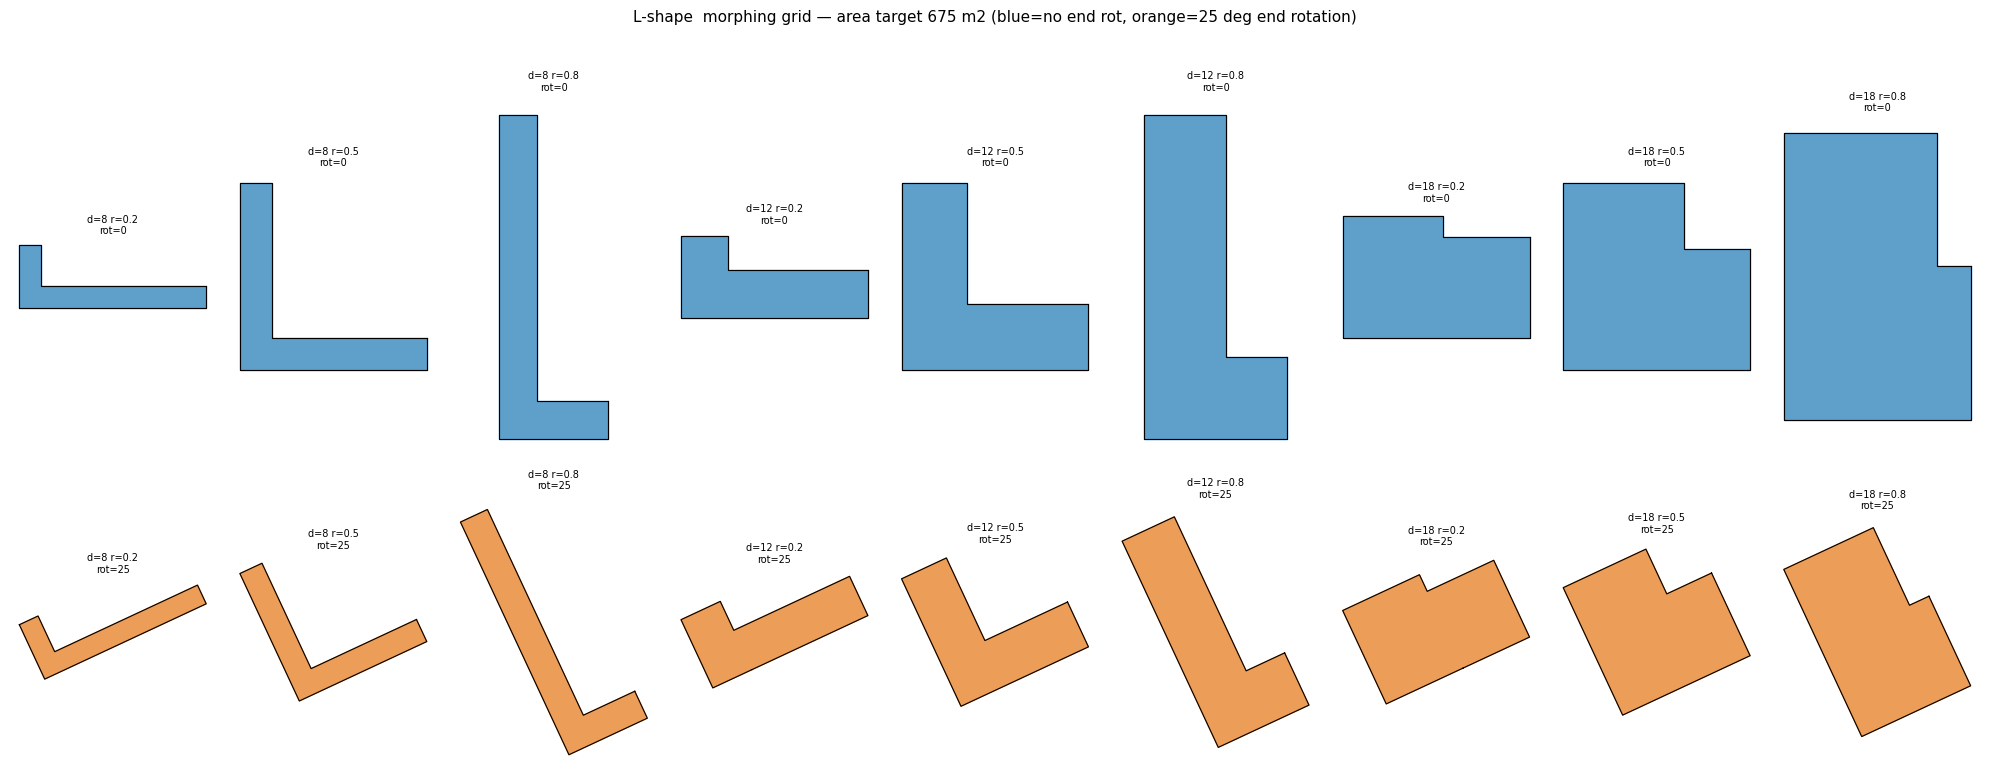

In [3]:
spec = shape_variable_spec(BTYPE_1, AREA_1)
print(f'Shape variables for {BTYPE_1}:', spec['names'])
print(f'  Leaf wing indices: {spec["leaf_wing_indices"]}')

# Show a grid: rows = shape_ratio, cols = building_depth
depths = [8, 12, 18]
ratios = [0.2, 0.5, 0.8]
end_rots = [0, 25]   # 0 = no rotation, 25 = 25 deg rotation on leaf wings

fig, axes = plt.subplots(len(end_rots), len(ratios)*len(depths),
                          figsize=(20, 8))
col = 0
for depth in depths:
    for ratio in ratios:
        for row, erot in enumerate(end_rots):
            ax = axes[row][col] if len(axes.shape) > 1 else axes[col]
            n_leaf = len(spec['leaf_wing_indices'])
            vars_in = [depth, ratio] + [erot]*n_leaf
            poly = apply_shape_variables(BTYPE_1, AREA_1, vars_in, spec['leaf_wing_indices'])
            xs, ys = zip(*poly.exterior.coords)
            ax.fill(xs, ys, alpha=0.75, color='#2980b9' if erot==0 else '#e67e22')
            ax.plot(xs, ys, 'k-', lw=0.8)
            ax.set_aspect('equal'); ax.axis('off')
            ax.set_title(f'd={depth} r={ratio}\nrot={erot}', fontsize=7)
            actual = round(poly.area, 1)
            ax.set_xlabel(f'{actual} m2', fontsize=6)
        col += 1

fig.suptitle(f'{BTYPE_1}-shape  morphing grid — area target {AREA_1:.0f} m2 '
             f'(blue=no end rot, orange=25 deg end rotation)',
             fontsize=11, y=1.02)
plt.tight_layout(); plt.show()

## 3. Registered Objectives & Custom Combinations

Objective configs are just dicts — any user intent can be translated to a list by the LLM.

In [4]:
# Two example objective configs — same building, different priorities
cfg_view_priority = [
    {"name": "unblocked_view",      "weight": 0.7},
    {"name": "attractor_view",       "weight": 0.2, "attractors": attractors},
    {"name": "clearance_from_site",  "weight": 0.1},
]
cfg_attractor_priority = [
    {"name": "unblocked_view",      "weight": 0.3},
    {"name": "attractor_view",       "weight": 0.6, "attractors": attractors},
    {"name": "clearance_from_site",  "weight": 0.1},
]

from shapely.geometry import Polygon as _Poly

# Test building at fixed position
test_bnd = bld_origin_1
test_poly = _Poly([(p[0],p[1]) for p in test_bnd])
test_cx = test_poly.centroid.x + 40
test_cy = test_poly.centroid.y + 50
placed = affinity.translate(base_poly_1, xoff=test_cx, yoff=test_cy)
placed_bnd = [[round(float(x),3),round(float(y),3),0.0] for x,y in placed.exterior.coords]
site_poly = _Poly([(p[0],p[1]) for p in site_boundary])

for label, cfg in [('View-priority', cfg_view_priority),
                    ('Attractor-priority', cfg_attractor_priority)]:
    score, per_obj = evaluate_combined_score(
        placed_bnd, cfg,
        obstacles=external_obstacles,
        site_polygon=site_poly,
        candidate_polygon=placed,
        piece_length=PIECE_LENGTH, ray_length=RAY_LENGTH,
    )
    print(f'\n{label} config:')
    for k, v in per_obj.items():
        print(f'  {k:28s}: {v:.4f}')
    print(f'  {"combined_score":28s}: {score:.4f}')


View-priority config:
  unblocked_view              : 0.5000
  attractor_view              : 1.0000
  clearance_from_site         : 1.0000
  combined_score              : 0.6500

Attractor-priority config:
  unblocked_view              : 0.5000
  attractor_view              : 1.0000
  clearance_from_site         : 1.0000
  combined_score              : 0.8500


## 4. Valid Seed Points

Valid seed points for Building 1: 5880


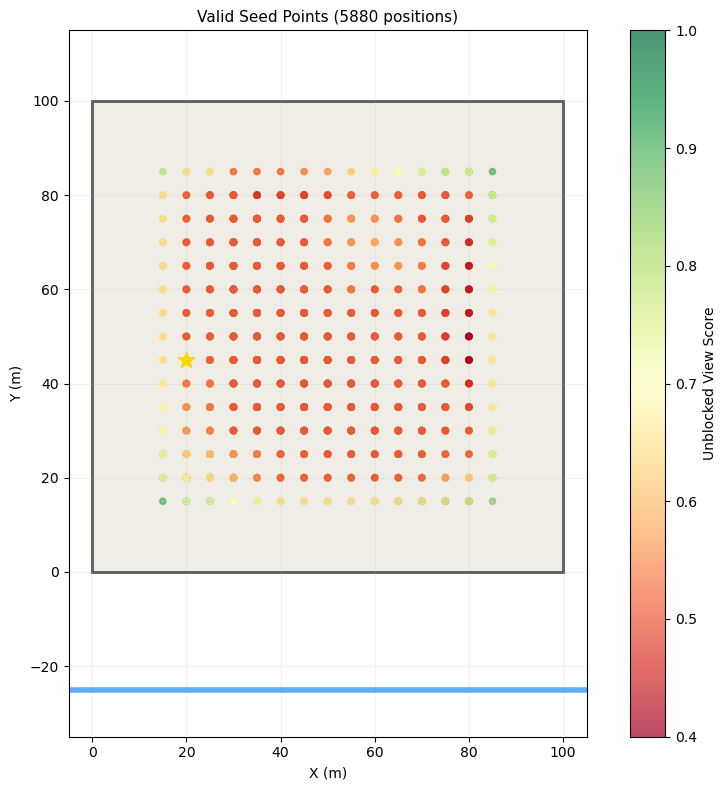

In [5]:
cands_1 = sample_valid_placements(bld_origin_1, site_boundary,
                                   rotation_step_degrees=10, grid_step=5.0)
ranked_1 = rank_placements_by_view(cands_1, external_obstacles,
                                    piece_length=PIECE_LENGTH, ray_length=RAY_LENGTH)
print(f'Valid seed points for Building 1: {len(ranked_1)}')

fig, ax = plt.subplots(figsize=(9, 8))
ax.add_patch(plt.Polygon([(p[0],p[1]) for p in site_boundary[:-1]],
                         fc='#f0ede6', ec='#555', lw=2, zorder=1))
for att in attractors:
    ax.plot([att['geometry'][0][0], att['geometry'][1][0]],
            [att['geometry'][0][1], att['geometry'][1][1]],
            color='#1a8cff', lw=4, alpha=0.7)
xs = [p['centroid_xy'][0] for p in ranked_1]
ys = [p['centroid_xy'][1] for p in ranked_1]
vs = [p['view_score']     for p in ranked_1]
sc = ax.scatter(xs, ys, c=vs, cmap='RdYlGn', s=20, alpha=0.7, zorder=3)
plt.colorbar(sc, label='Unblocked View Score')
best = ranked_1[0]
ax.scatter([best['centroid_xy'][0]], [best['centroid_xy'][1]],
           color='gold', s=160, marker='*', zorder=5)
ax.set_title(f'Valid Seed Points ({len(ranked_1)} positions)', fontsize=11)
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
ax.set_xlim(-5, 105); ax.set_ylim(-35, 115)
ax.set_aspect('equal'); ax.grid(True, alpha=0.15)
plt.tight_layout(); plt.show()

## 5. Single-Building NSGA-II — Fixed Shape + Extensible Objectives

Two objectives on the Pareto front: `unblocked_view` vs `attractor_view`.

In [6]:
print('Running single-building NSGA-II (fixed shape)...')

opt1 = optimize_view_placement(
    boundary=bld_origin_1,
    site_boundary=site_boundary,
    obstacles=external_obstacles,
    objective_configs=cfg_view_priority,
    optimize_shape=False,
    piece_length=PIECE_LENGTH,
    ray_length=RAY_LENGTH,
    rotation_step_degrees=10,
    population_size=50,
    generation_count=100,
    random_seed=42,
    saved_option_count=15,
)

print(f'Pareto solutions: {opt1["pareto_solution_count"]}')
print(f'{"Rank":>4}  {"Combined":>8}  {"Unblocked":>9}  {"Attractor":>9}  {"Rotation":>8}')
print('-' * 50)
for s in opt1['pareto_solutions']:
    print(f'{s["rank"]:>4}  {s["combined_score"]:>8.4f}  '
          f'{s["unblocked_view_score"]:>9.4f}  {s["attractor_view_score"]:>9.4f}  '
          f'{s["rotation_degrees"]:>8}')

Running single-building NSGA-II (fixed shape)...


Pareto solutions: 15
Rank  Combined  Unblocked  Attractor  Rotation
--------------------------------------------------
   1    1.0000     1.0000     1.0000       320
   2    1.0000     1.0000     1.0000       310
   3    1.0000     1.0000     1.0000       310
   4    1.0000     1.0000     1.0000       320
   5    1.0000     1.0000     1.0000       320
   6    0.9994     1.0000     1.0000       240
   7    0.9994     1.0000     1.0000       240
   8    0.9956     1.0000     1.0000       310
   9    0.9914     1.0000     1.0000       310
  10    0.9906     1.0000     1.0000       320
  11    0.9882     1.0000     1.0000       320
  12    0.9761     1.0000     1.0000       310
  13    0.9755     1.0000     1.0000       310
  14    0.9722     1.0000     1.0000       310
  15    0.9717     1.0000     1.0000       320


## 6. Single-Building NSGA-II — Free Wing Shape

Wing shape variables added: `building_depth`, `shape_ratio`, and one `end_rot` per leaf wing.  
Area is **exactly preserved** across all Pareto solutions.

In [7]:
spec1 = shape_variable_spec(BTYPE_1, AREA_1)
print(f'Shape variables for {BTYPE_1}: {spec1["names"]}')
print('Running single-building NSGA-II (wing-parametric shape)...')

opt1_free = optimize_view_placement(
    boundary=bld_origin_1,
    site_boundary=site_boundary,
    obstacles=external_obstacles,
    objective_configs=cfg_view_priority,
    optimize_shape=True,
    building_type=BTYPE_1,
    piece_length=PIECE_LENGTH,
    ray_length=RAY_LENGTH,
    rotation_step_degrees=10,
    population_size=50,
    generation_count=100,
    random_seed=42,
    saved_option_count=10,
)

print(f'Pareto solutions (free shape): {opt1_free["pareto_solution_count"]}')
print(f'{"Rank":>4}  {"Combined":>8}  {"Unblocked":>9}  {"Attractor":>9}  '
      f'{"Depth":>6}  {"Ratio":>6}  EndRots')
print('-' * 70)
for s in opt1_free['pareto_solutions']:
    er = ', '.join(f'{v:.0f}' for v in s['end_wing_rotations'].values())
    print(f'{s["rank"]:>4}  {s["combined_score"]:>8.4f}  '
          f'{s["unblocked_view_score"]:>9.4f}  {s["attractor_view_score"]:>9.4f}  '
          f'{s["building_depth"]:>6.1f}  {s["shape_ratio"]:>6.3f}  [{er}]')

Shape variables for L: ['building_depth', 'shape_ratio', 'end_rot_0', 'end_rot_1']
Running single-building NSGA-II (wing-parametric shape)...


Pareto solutions (free shape): 10
Rank  Combined  Unblocked  Attractor   Depth   Ratio  EndRots
----------------------------------------------------------------------
   1    0.9642     1.0000     1.0000    17.4   0.201  [0, -3]
   2    0.9438     1.0000     1.0000    17.7   0.407  [-6, -7]
   3    0.9436     1.0000     1.0000    17.9   0.173  [5, -7]
   4    0.9435     1.0000     1.0000    17.9   0.173  [5, -7]
   5    0.9419     1.0000     1.0000    20.7   0.201  [0, -7]
   6    0.9419     1.0000     1.0000    20.7   0.141  [-5, 8]
   7    0.9393     1.0000     1.0000    16.9   0.383  [5, 1]
   8    0.9389     1.0000     1.0000    17.4   0.174  [-2, -2]
   9    0.9389     1.0000     1.0000    17.4   0.174  [-2, -2]
  10    0.9385     1.0000     1.0000    19.1   0.201  [0, -7]


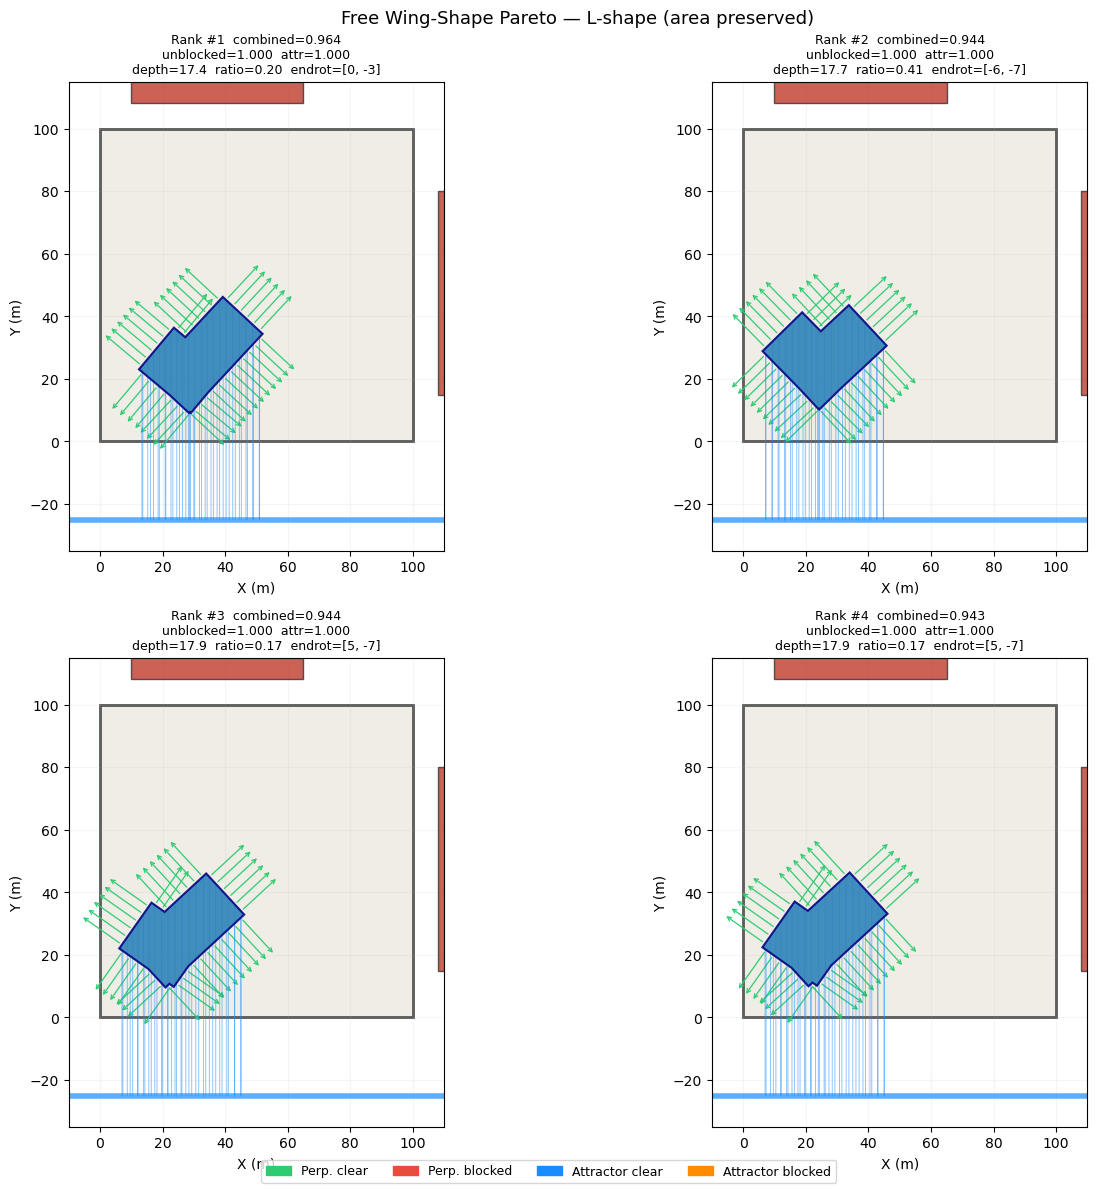

In [8]:
# Visualise top 4 free-shape placements — show actual polygon shape
n_show = min(4, len(opt1_free['pareto_solutions']))
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

def draw_base(ax, show_attractor=True):
    ax.add_patch(plt.Polygon([(p[0],p[1]) for p in site_boundary[:-1]],
                             fc='#f0ede6', ec='#555', lw=2, zorder=1))
    for obs in external_obstacles:
        ax.add_patch(plt.Polygon([(p[0],p[1]) for p in obs[:-1]],
                                 fc='#c0392b', ec='#333', lw=1, alpha=0.8, zorder=2))
    if show_attractor:
        for att in attractors:
            ax.plot([att['geometry'][0][0], att['geometry'][1][0]],
                    [att['geometry'][0][1], att['geometry'][1][1]],
                    color='#1a8cff', lw=4, alpha=0.7)

for i, sol in enumerate(opt1_free['pareto_solutions'][:n_show]):
    ax = axes[i]
    draw_base(ax)

    bnd = sol['boundary']
    r_v = evaluate_building_views(bnd, external_obstacles, piece_length=PIECE_LENGTH,
                                   ray_length=RAY_LENGTH, return_ray_detail=True)
    r_a = evaluate_attractor_views(bnd, attractors, external_obstacles,
                                    piece_length=PIECE_LENGTH, return_ray_detail=True)

    VL = 16
    for tp in r_v['per_test_point']:
        if not tp.get('rays'): continue
        ray = tp['rays'][0]
        ang = math.radians(ray['angle_degrees'])
        ox, oy = tp['point'][0]+math.cos(ang)*0.1, tp['point'][1]+math.sin(ang)*0.1
        c = '#e74c3c' if ray['blocked'] else '#2ecc71'
        ax.annotate('', xy=(ox+math.cos(ang)*VL, oy+math.sin(ang)*VL), xytext=(ox, oy),
                    arrowprops=dict(arrowstyle='->', color=c, lw=0.9, mutation_scale=7), zorder=3)
    for tp in r_a['per_test_point']:
        px, py = tp['point'][0], tp['point'][1]
        for ar in tp.get('attractor_rays', []):
            c = '#1a8cff' if not ar['blocked'] else '#ff8c00'
            ax.plot([px, ar['target_point'][0]], [py, ar['target_point'][1]],
                    color=c, lw=0.7, alpha=0.5, zorder=3)

    ax.add_patch(plt.Polygon([(p[0],p[1]) for p in bnd[:-1]],
                             fc='#2980b9', ec='navy', lw=1.5, alpha=0.88, zorder=4))

    er = ', '.join(f'{v:.0f}' for v in sol['end_wing_rotations'].values())
    ax.set_title(
        f'Rank #{sol["rank"]}  combined={sol["combined_score"]:.3f}\n'
        f'unblocked={sol["unblocked_view_score"]:.3f}  attr={sol["attractor_view_score"]:.3f}\n'
        f'depth={sol["building_depth"]:.1f}  ratio={sol["shape_ratio"]:.2f}  endrot=[{er}]',
        fontsize=9)
    ax.set_xlim(-10, 110); ax.set_ylim(-35, 115)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.12)
    ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')

for j in range(n_show, 4):
    axes[j].axis('off')

handles = [
    mpatches.Patch(color='#2ecc71', label='Perp. clear'),
    mpatches.Patch(color='#e74c3c', label='Perp. blocked'),
    mpatches.Patch(color='#1a8cff', label='Attractor clear'),
    mpatches.Patch(color='#ff8c00', label='Attractor blocked'),
]
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=9)
fig.suptitle(f'Free Wing-Shape Pareto — {BTYPE_1}-shape (area preserved)', fontsize=13)
plt.tight_layout(); plt.show()

## 7. Pareto Front — Unblocked vs. Attractor (single building)

Fixed shape and free shape on the same plot to compare Pareto front coverage.

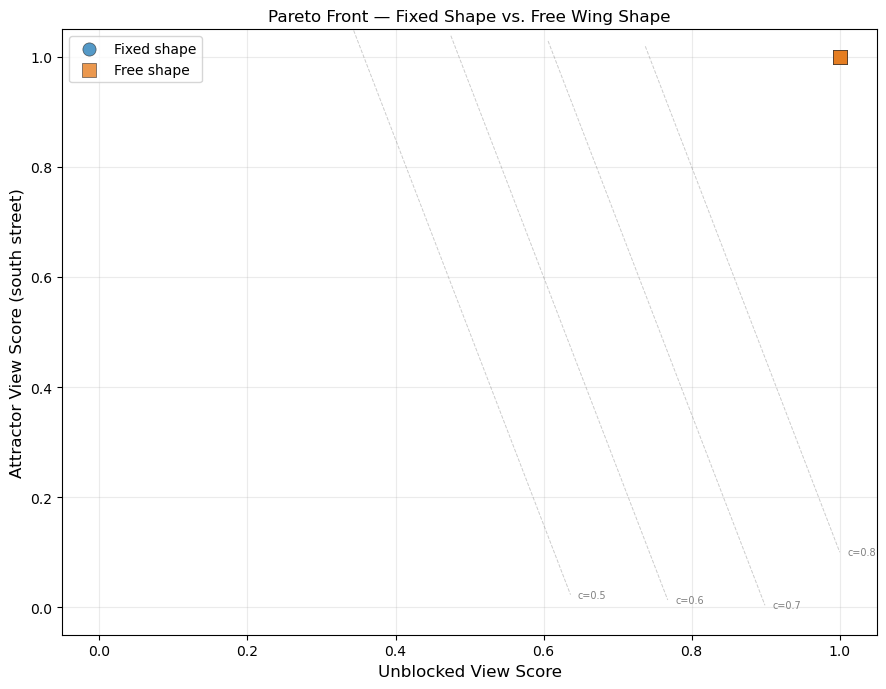

In [9]:
fig, ax = plt.subplots(figsize=(9, 7))

for sols, label, marker, color in [
    (opt1['pareto_solutions'],      'Fixed shape', 'o', '#2980b9'),
    (opt1_free['pareto_solutions'], 'Free shape',  's', '#e67e22'),
]:
    u = [s['unblocked_view_score'] for s in sols]
    a = [s['attractor_view_score'] for s in sols]
    ax.scatter(u, a, marker=marker, color=color, s=90, alpha=0.8,
               edgecolors='#333', linewidths=0.5, label=label, zorder=3)

# Iso-combined-score contours
W_V = cfg_view_priority[0]['weight'] / (cfg_view_priority[0]['weight'] + cfg_view_priority[1]['weight'])
W_A = 1 - W_V
u_lin = np.linspace(0, 1, 100)
for c_lev in [0.5, 0.6, 0.7, 0.8]:
    a_lin = (c_lev - W_V * u_lin) / W_A
    mask = (a_lin >= 0) & (a_lin <= 1.05)
    if mask.any():
        ax.plot(u_lin[mask], a_lin[mask], '--', lw=0.7, alpha=0.4, color='gray')
        ax.text(u_lin[mask][-1]+0.01, a_lin[mask][-1],
                f'c={c_lev}', fontsize=7, color='gray', va='center')

ax.set_xlabel('Unblocked View Score', fontsize=12)
ax.set_ylabel('Attractor View Score (south street)', fontsize=12)
ax.set_title('Pareto Front — Fixed Shape vs. Free Wing Shape', fontsize=12)
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=10); ax.grid(True, alpha=0.25)
plt.tight_layout(); plt.show()

## 8. Two-Building Joint NSGA-II — Extensible Objectives

In [10]:
print('Running two-building NSGA-II (may take 2-4 min)...')

opt2 = optimize_two_building_placement(
    boundary_1=bld_origin_1,
    boundary_2=bld_origin_2,
    site_boundary=site_boundary,
    external_obstacles=external_obstacles,
    objective_configs=cfg_view_priority,
    optimize_shape=False,
    piece_length=PIECE_LENGTH,
    ray_length=RAY_LENGTH,
    rotation_step_degrees=10,
    population_size=60,
    generation_count=150,
    random_seed=42,
    saved_option_count=15,
)

print(f'Pareto solutions: {opt2["pareto_solution_count"]}')
print(f'Best avg combined: {opt2["best_avg_combined_score"]:.4f}')

Running two-building NSGA-II (may take 2-4 min)...


Pareto solutions: 15
Best avg combined: 0.9740


In [11]:
# Results table
print(f'{"Rank":>4}  {"AvgComb":>8}  '
      f'{"B1_unb":>7}  {"B1_att":>7}  {"B1_comb":>8}  '
      f'{"B2_unb":>7}  {"B2_att":>7}  {"B2_comb":>8}  {"Overlap":>7}')
print('-' * 80)
for s in opt2['pareto_solutions']:
    b1, b2 = s['building_1'], s['building_2']
    print(f'{s["rank"]:>4}  {s["avg_combined_score"]:>8.4f}  '
          f'{b1["unblocked_view_score"]:>7.3f}  {b1["attractor_view_score"]:>7.3f}  {b1["combined_score"]:>8.4f}  '
          f'{b2["unblocked_view_score"]:>7.3f}  {b2["attractor_view_score"]:>7.3f}  {b2["combined_score"]:>8.4f}  '
          f'{s["overlap_area_sqm"]:>7.2f}')

Rank   AvgComb   B1_unb   B1_att   B1_comb   B2_unb   B2_att   B2_comb  Overlap
--------------------------------------------------------------------------------
   1    0.9740    1.000    1.000    0.9868    0.944    1.000    0.9611     0.00
   2    0.9740    1.000    1.000    0.9868    0.944    1.000    0.9611     0.00
   3    0.9723    1.000    1.000    0.9641    0.972    1.000    0.9806     0.00
   4    0.9708    1.000    1.000    1.0000    0.917    1.000    0.9417     0.00
   5    0.9708    1.000    1.000    1.0000    0.917    1.000    0.9417     0.00
   6    0.9708    1.000    1.000    1.0000    0.917    1.000    0.9417     0.00
   7    0.9708    1.000    1.000    1.0000    0.917    1.000    0.9417     0.00
   8    0.9708    1.000    1.000    1.0000    0.917    1.000    0.9417     0.00
   9    0.9708    1.000    1.000    1.0000    0.917    1.000    0.9417     0.00
  10    0.9708    1.000    1.000    1.0000    0.917    1.000    0.9417     0.00
  11    0.9708    1.000    1.000    1.0

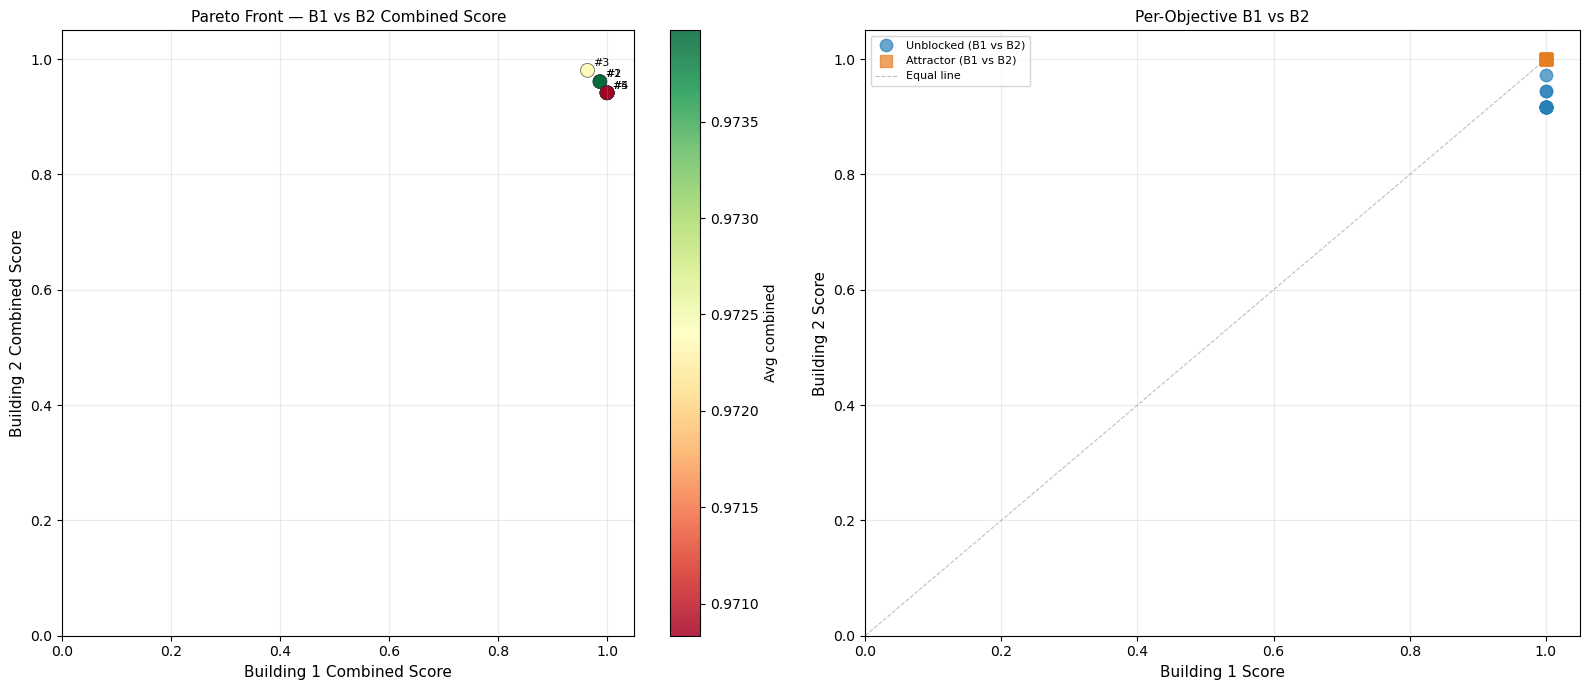

In [12]:
# Pareto front + per-building breakdown
sols = opt2['pareto_solutions']
c1s = [s['building_1']['combined_score'] for s in sols]
c2s = [s['building_2']['combined_score'] for s in sols]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Combined Pareto
ax = axes[0]
sc = ax.scatter(c1s, c2s, c=[(a+b)/2 for a,b in zip(c1s,c2s)],
                cmap='RdYlGn', s=100, alpha=0.85, edgecolors='#333', linewidths=0.5)
plt.colorbar(sc, label='Avg combined', ax=ax)
for s in sols[:5]:
    ax.annotate(f'#{s["rank"]}',
                xy=(s['building_1']['combined_score'], s['building_2']['combined_score']),
                xytext=(4,3), textcoords='offset points', fontsize=8)
ax.set_xlabel('Building 1 Combined Score', fontsize=11)
ax.set_ylabel('Building 2 Combined Score', fontsize=11)
ax.set_title('Pareto Front — B1 vs B2 Combined Score', fontsize=11)
ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.25)

# Per-objective breakdown scatter
ax = axes[1]
for key, color, marker, label in [
    ('unblocked_view_score', '#2980b9', 'o', 'Unblocked'),
    ('attractor_view_score', '#e67e22', 's', 'Attractor'),
]:
    b1_vals = [s['building_1'][key] for s in sols]
    b2_vals = [s['building_2'][key] for s in sols]
    ax.scatter(b1_vals, b2_vals, color=color, marker=marker, s=80,
               alpha=0.7, label=f'{label} (B1 vs B2)', zorder=3)

ax.plot([0,1],[0,1],'--',color='gray',lw=0.8,alpha=0.5,label='Equal line')
ax.set_xlabel('Building 1 Score', fontsize=11)
ax.set_ylabel('Building 2 Score', fontsize=11)
ax.set_title('Per-Objective B1 vs B2', fontsize=11)
ax.set_xlim(0,1.05); ax.set_ylim(0,1.05)
ax.legend(fontsize=8); ax.grid(True, alpha=0.25)

plt.tight_layout(); plt.show()

## 9. Top Solutions — Site Maps

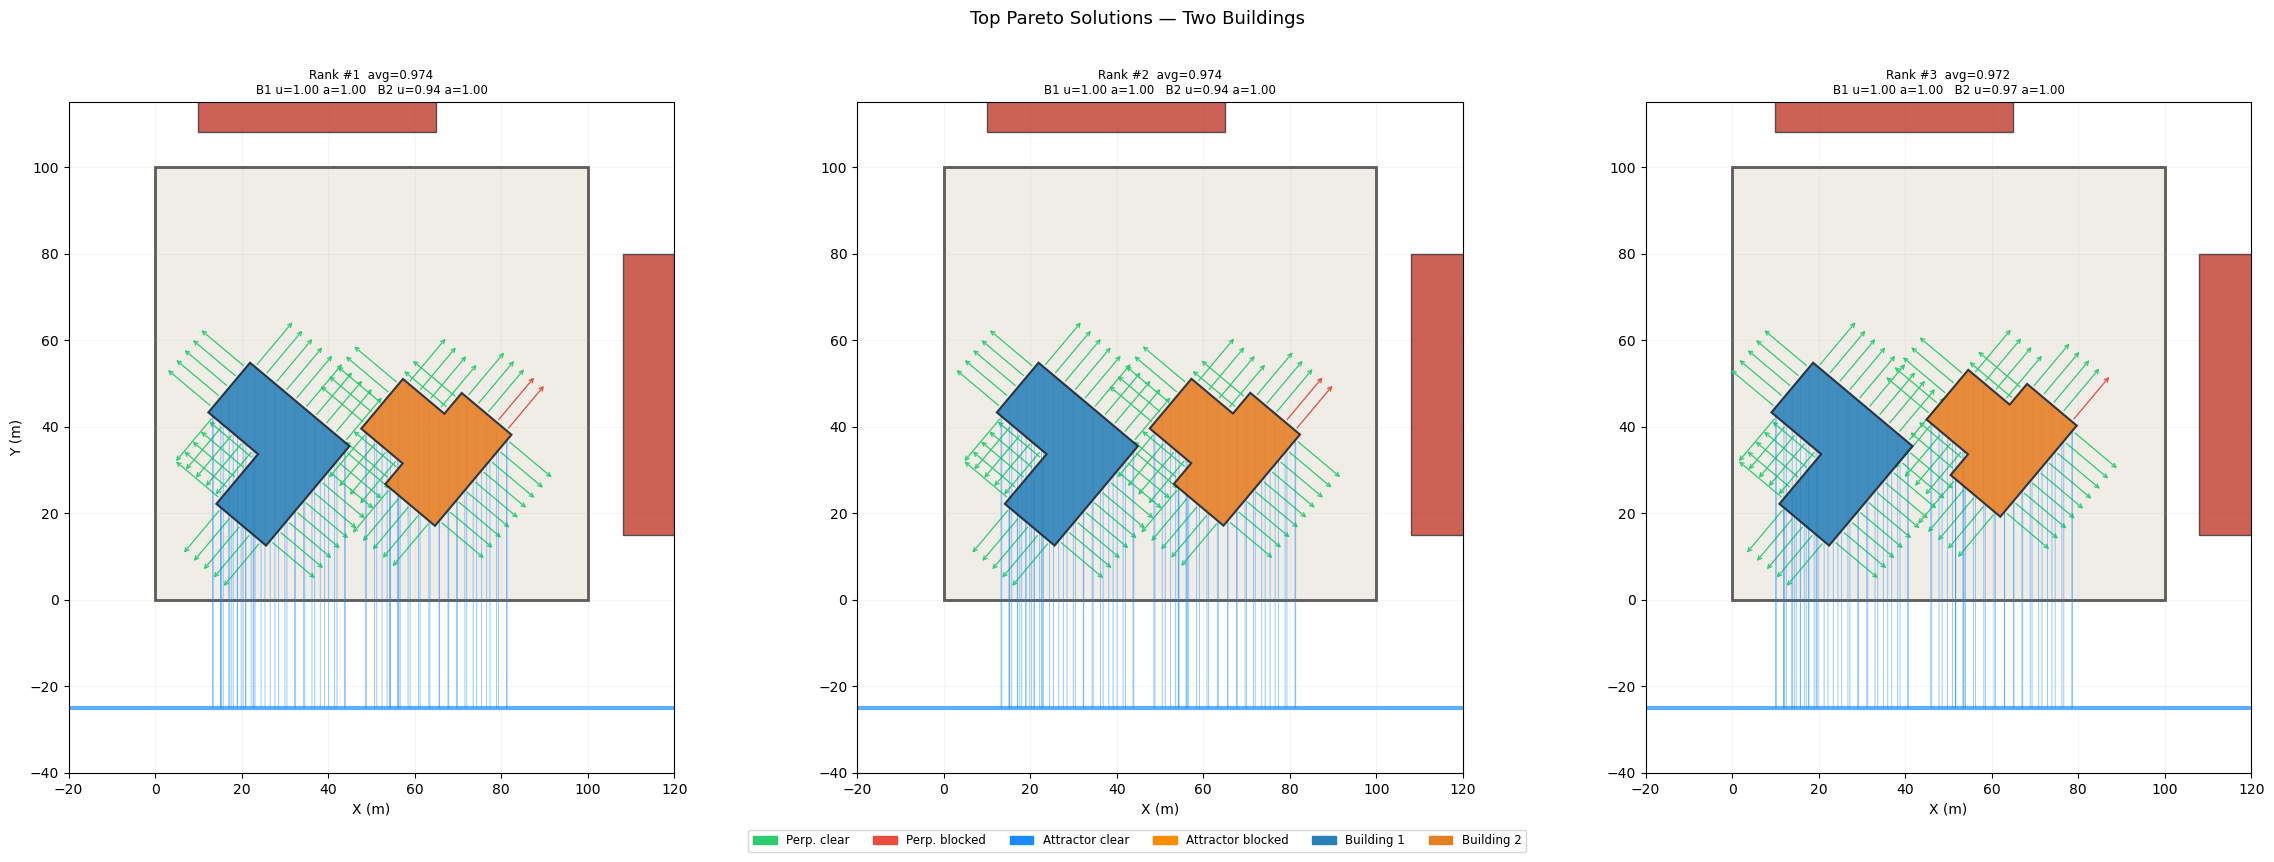

In [13]:
def plot_two_bld_solution(sol, ext_obs, site_bnd, attr_list, piece_len, ray_len, ax):
    b1, b2 = sol['building_1'], sol['building_2']
    r1_v = evaluate_building_views(b1['boundary'], ext_obs+[b2['boundary']],
                                    piece_length=piece_len, ray_length=ray_len, return_ray_detail=True)
    r1_a = evaluate_attractor_views(b1['boundary'], attr_list, ext_obs+[b2['boundary']],
                                     piece_length=piece_len, return_ray_detail=True)
    r2_v = evaluate_building_views(b2['boundary'], ext_obs+[b1['boundary']],
                                    piece_length=piece_len, ray_length=ray_len, return_ray_detail=True)
    r2_a = evaluate_attractor_views(b2['boundary'], attr_list, ext_obs+[b1['boundary']],
                                     piece_length=piece_len, return_ray_detail=True)

    ax.add_patch(plt.Polygon([(p[0],p[1]) for p in site_bnd[:-1]],
                             fc='#f0ede6', ec='#555', lw=2, zorder=1))
    for obs in ext_obs:
        ax.add_patch(plt.Polygon([(p[0],p[1]) for p in obs[:-1]],
                                 fc='#c0392b', ec='#333', lw=1, alpha=0.8, zorder=2))
    for att in attr_list:
        ax.plot([att['geometry'][0][0], att['geometry'][1][0]],
                [att['geometry'][0][1], att['geometry'][1][1]],
                color='#1a8cff', lw=3, alpha=0.7, zorder=2)

    VL = 14
    for (bnd, rv, ra, fc) in [(b1['boundary'],r1_v,r1_a,'#2980b9'),
                               (b2['boundary'],r2_v,r2_a,'#e67e22')]:
        for tp in rv['per_test_point']:
            if not tp.get('rays'): continue
            ray = tp['rays'][0]
            ang = math.radians(ray['angle_degrees'])
            ox, oy = tp['point'][0]+math.cos(ang)*0.1, tp['point'][1]+math.sin(ang)*0.1
            c = '#e74c3c' if ray['blocked'] else '#2ecc71'
            ax.annotate('', xy=(ox+math.cos(ang)*VL, oy+math.sin(ang)*VL), xytext=(ox, oy),
                        arrowprops=dict(arrowstyle='->', color=c, lw=0.9, mutation_scale=7), zorder=3)
        for tp in ra['per_test_point']:
            px, py = tp['point'][0], tp['point'][1]
            for ar in tp.get('attractor_rays', []):
                c = '#1a8cff' if not ar['blocked'] else '#ff8c00'
                ax.plot([px, ar['target_point'][0]], [py, ar['target_point'][1]],
                        color=c, lw=0.7, alpha=0.45, zorder=3)
        ax.add_patch(plt.Polygon([(p[0],p[1]) for p in bnd[:-1]],
                                 fc=fc, ec='#1a252f', lw=1.5, alpha=0.88, zorder=4))

    b1d, b2d = sol['building_1'], sol['building_2']
    ax.set_title(
        f'Rank #{sol["rank"]}  avg={sol["avg_combined_score"]:.3f}\n'
        f'B1 u={b1d["unblocked_view_score"]:.2f} a={b1d["attractor_view_score"]:.2f}   '
        f'B2 u={b2d["unblocked_view_score"]:.2f} a={b2d["attractor_view_score"]:.2f}',
        fontsize=8.5)
    ax.set_xlim(-20, 120); ax.set_ylim(-40, 115)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.12)


n_show = min(3, len(opt2['pareto_solutions']))
fig, axes = plt.subplots(1, n_show, figsize=(8*n_show, 8))
if n_show == 1: axes = [axes]
for i, sol in enumerate(opt2['pareto_solutions'][:n_show]):
    plot_two_bld_solution(sol, external_obstacles, site_boundary,
                          attractors, PIECE_LENGTH, RAY_LENGTH, axes[i])
    axes[i].set_xlabel('X (m)')
    if i == 0: axes[i].set_ylabel('Y (m)')

handles = [
    mpatches.Patch(color='#2ecc71', label='Perp. clear'),
    mpatches.Patch(color='#e74c3c', label='Perp. blocked'),
    mpatches.Patch(color='#1a8cff', label='Attractor clear'),
    mpatches.Patch(color='#ff8c00', label='Attractor blocked'),
    mpatches.Patch(color='#2980b9', label='Building 1'),
    mpatches.Patch(color='#e67e22', label='Building 2'),
]
fig.legend(handles=handles, loc='lower center', ncol=6, fontsize=8.5, bbox_to_anchor=(0.5,-0.04))
fig.suptitle('Top Pareto Solutions — Two Buildings', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

## 10. Site Setbacks & Buildable Zone

The **buildable zone** is the site polygon minus per-edge setbacks.
- Larger road → bigger setback (configurable ratio, e.g. 40% of road width)
- Placement optimizer seeds only positions inside this inset polygon
- Hard constraint G in NSGA-II uses `buildable_zone.contains(building)` instead of raw site

Site area:       10000.0 m2
Buildable area:   8277.0 m2
Setback area:     1723.0 m2
Buildable frac:    0.828

Edge   Length  Setback   Road W  Midpoint
   0    100.0      8.0   20.0 m  [50.0, 0.0]
   1    100.0      4.0   10.0 m  [100.0, 50.0]
   2    100.0      3.0      n/a  [50.0, 100.0]
   3    100.0      3.0      n/a  [0.0, 50.0]


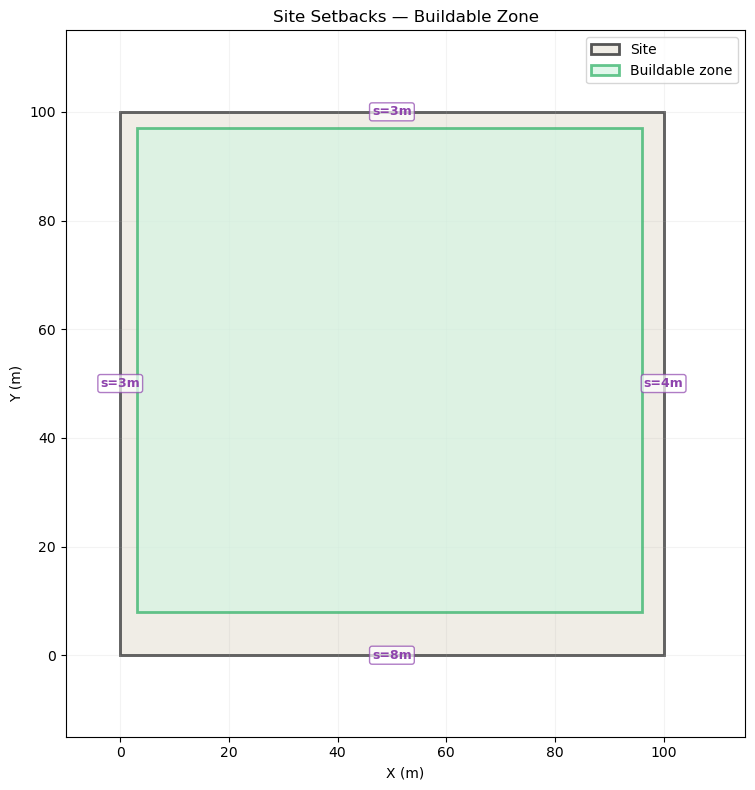

In [14]:
from agent.tools.site_setback import compute_buildable_zone, setback_summary

# Site edges (CCW): south=0, east=1, north=2, west=3
# Suppose south edge faces a major arterial road (20 m wide) → big setback
# East edge faces a collector road (10 m) → medium setback
# Others face small lanes → use default
SETBACK_PARAMS = dict(
    default_setback=3.0,
    edge_road_widths={
        0: 20.0,   # south edge — arterial
        1: 10.0,   # east edge — collector
    },
    road_setback_ratio=0.4,
    min_setback=3.0,
)

summary = setback_summary(site_boundary, **SETBACK_PARAMS)
print(f'Site area:      {summary["site_area_sqm"]:>8.1f} m2')
print(f'Buildable area: {summary["buildable_area_sqm"]:>8.1f} m2')
print(f'Setback area:   {summary["setback_area_sqm"]:>8.1f} m2')
print(f'Buildable frac: {summary["buildable_fraction"]:>8.3f}')
print()
print(f'{"Edge":>4}  {"Length":>7}  {"Setback":>7}  {"Road W":>7}  Midpoint')
for e in summary['edges']:
    rw = f'{e["road_width_m"]} m' if e["road_width_m"] is not None else 'n/a'
    print(f'{e["edge_index"]:>4}  {e["edge_length_m"]:>7.1f}  {e["setback_m"]:>7.1f}  {rw:>7}  {e["midpoint"]}')

# Visualise site + buildable zone
buildable_bnd = summary['buildable_boundary']
fig, ax = plt.subplots(figsize=(8, 8))
ax.add_patch(plt.Polygon([(p[0],p[1]) for p in site_boundary[:-1]],
                         fc='#f0ede6', ec='#555', lw=2, label='Site', zorder=1))
buildable_pts = [(p[0],p[1]) for p in buildable_bnd[:-1]]
ax.add_patch(plt.Polygon(buildable_pts, fc='#d5f5e3', ec='#27ae60',
                         lw=2, alpha=0.7, label='Buildable zone', zorder=2))

# Annotate setback on each edge
coords = [(p[0],p[1]) for p in site_boundary[:-1]]
for e in summary['edges']:
    mx, my = e['midpoint']
    s = e['setback_m']
    ax.annotate(f's={s:.0f}m', xy=(mx, my), ha='center', va='center', fontsize=9,
                color='#8e44ad', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='#8e44ad', alpha=0.7))

ax.set_xlim(-10, 115); ax.set_ylim(-15, 115)
ax.set_aspect('equal'); ax.grid(True, alpha=0.15)
ax.set_title('Site Setbacks — Buildable Zone', fontsize=12)
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

## 11. Two-Building Optimization with Setbacks + Building Clearance

`min_building_separation` = minimum clearance between building footprints (added as hard constraint G[3]).  
Both buildings must stay inside the **buildable zone** (not just the raw site).

Running two-building NSGA-II with setbacks + 6 m clearance...


Pareto solutions: 12
Setbacks applied: True
Min separation:   6.0 m

Rank   AvgComb   B1_comb   B2_comb  Clearance  Overlap
------------------------------------------------------------
   1    0.9740    0.9869    0.9611       6.07     0.00
   2    0.9611    1.0000    0.9222       6.14     0.00
   3    0.9611    1.0000    0.9222       6.51     0.00
   4    0.9611    1.0000    0.9222       6.51     0.00
   5    0.9611    1.0000    0.9222       6.39     0.00
   6    0.9611    1.0000    0.9222       6.03     0.00
   7    0.9611    1.0000    0.9222       6.66     0.00
   8    0.9611    1.0000    0.9222       6.33     0.00
   9    0.9611    1.0000    0.9222       6.36     0.00
  10    0.9611    1.0000    0.9222       6.08     0.00
  11    0.9611    1.0000    0.9222       6.43     0.00
  12    0.9611    1.0000    0.9222       6.62     0.00


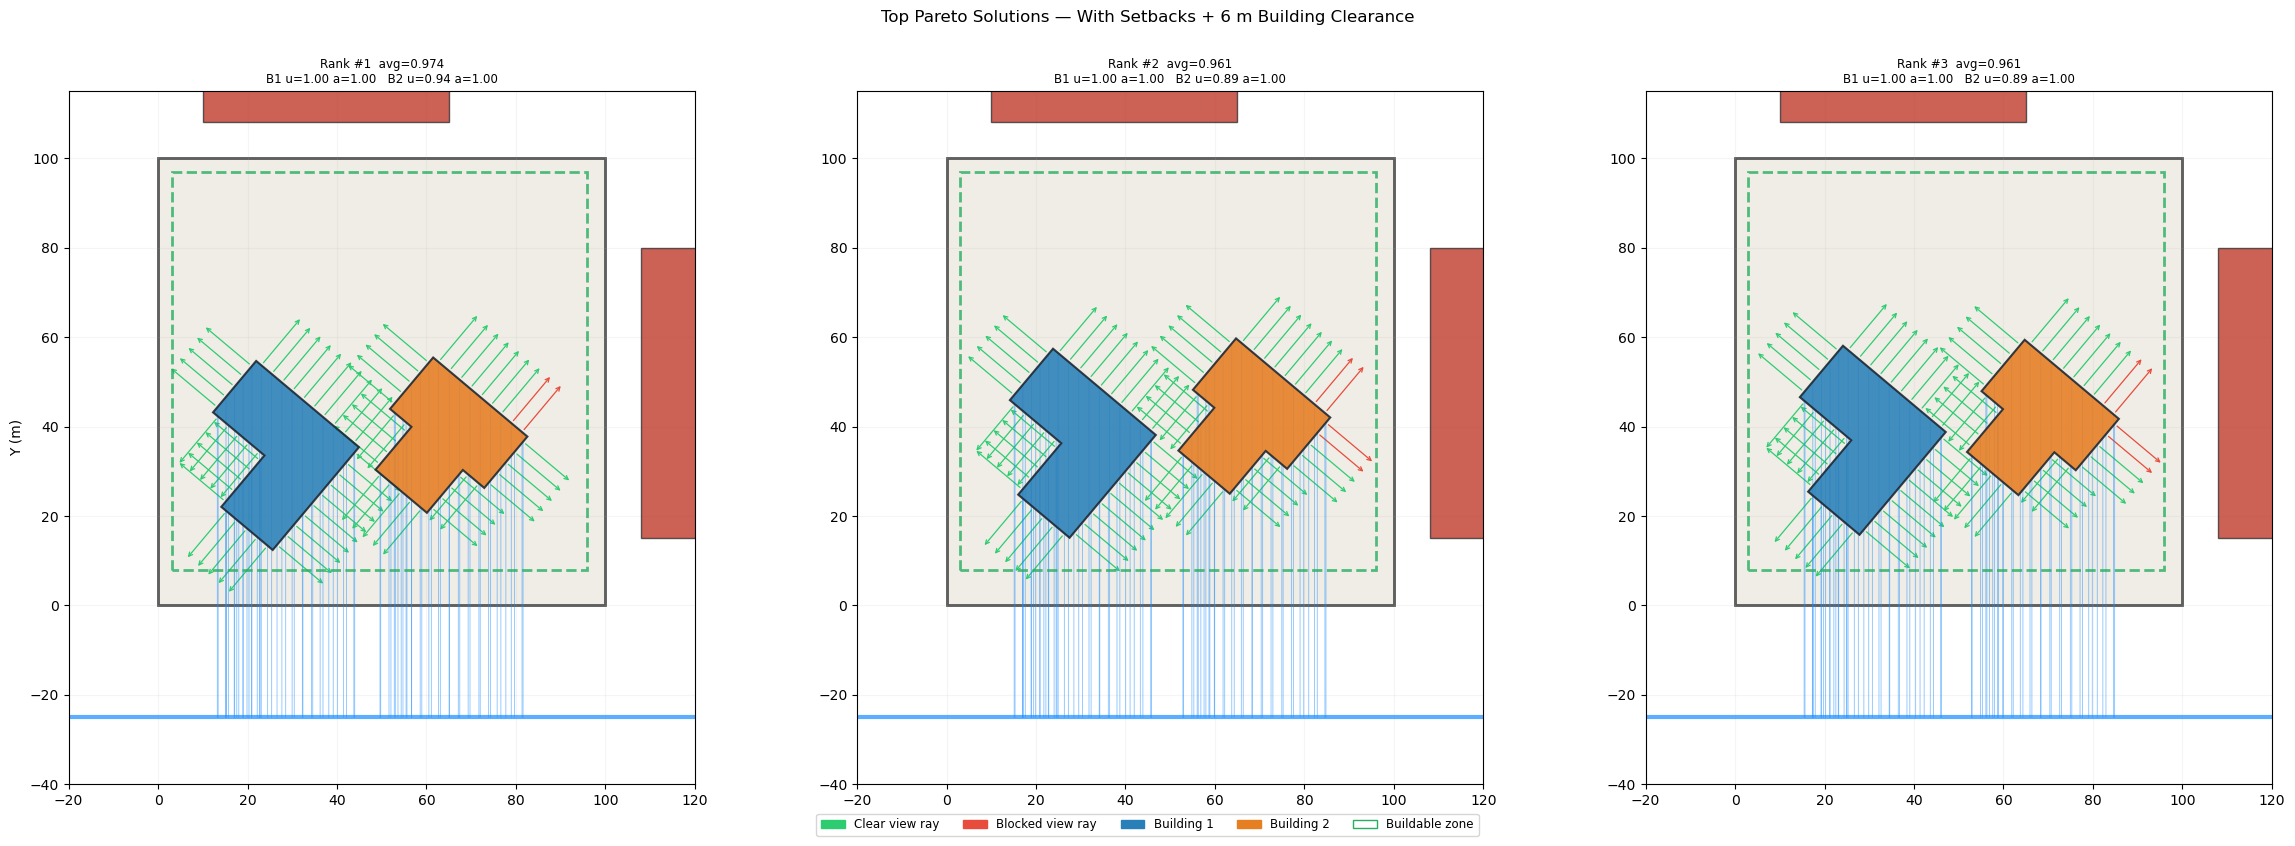

In [15]:
print('Running two-building NSGA-II with setbacks + 6 m clearance...')

opt2_setback = optimize_two_building_placement(
    boundary_1=bld_origin_1,
    boundary_2=bld_origin_2,
    site_boundary=site_boundary,
    external_obstacles=external_obstacles,
    objective_configs=cfg_view_priority,
    optimize_shape=False,
    site_setbacks=SETBACK_PARAMS,
    min_building_separation=6.0,
    piece_length=PIECE_LENGTH,
    ray_length=RAY_LENGTH,
    rotation_step_degrees=10,
    population_size=60,
    generation_count=150,
    random_seed=42,
    saved_option_count=12,
)

print(f'Pareto solutions: {opt2_setback["pareto_solution_count"]}')
print(f'Setbacks applied: {opt2_setback["site_setbacks_used"]}')
print(f'Min separation:   {opt2_setback["min_building_separation_m"]} m')
print()
print(f'{"Rank":>4}  {"AvgComb":>8}  {"B1_comb":>8}  {"B2_comb":>8}  '
      f'{"Clearance":>9}  {"Overlap":>7}')
print('-' * 60)
for s in opt2_setback['pareto_solutions']:
    print(f'{s["rank"]:>4}  {s["avg_combined_score"]:>8.4f}  '
          f'{s["building_1"]["combined_score"]:>8.4f}  '
          f'{s["building_2"]["combined_score"]:>8.4f}  '
          f'{s["clearance_between_buildings_m"]:>9.2f}  '
          f'{s["overlap_area_sqm"]:>7.2f}')

# Site map of top 3 solutions with buildable zone overlay
n_show_s = min(3, len(opt2_setback['pareto_solutions']))
fig, axes = plt.subplots(1, n_show_s, figsize=(8*n_show_s, 8))
if n_show_s == 1: axes = [axes]

buildable_pts = [(p[0],p[1]) for p in summary['buildable_boundary'][:-1]]

for i, sol in enumerate(opt2_setback['pareto_solutions'][:n_show_s]):
    ax = axes[i]
    plot_two_bld_solution(sol, external_obstacles, site_boundary,
                          attractors, PIECE_LENGTH, RAY_LENGTH, ax)
    ax.add_patch(plt.Polygon(buildable_pts, fill=False, ec='#27ae60',
                             lw=2, ls='--', alpha=0.8, zorder=5, label='Buildable zone'))
    if i == 0:
        ax.set_ylabel('Y (m)')

handles2 = [
    mpatches.Patch(color='#2ecc71', label='Clear view ray'),
    mpatches.Patch(color='#e74c3c', label='Blocked view ray'),
    mpatches.Patch(color='#2980b9', label='Building 1'),
    mpatches.Patch(color='#e67e22', label='Building 2'),
    mpatches.Patch(color='#27ae60', label='Buildable zone', fill=False),
]
fig.legend(handles=handles2, loc='lower center', ncol=5, fontsize=8.5, bbox_to_anchor=(0.5,-0.03))
fig.suptitle('Top Pareto Solutions — With Setbacks + 6 m Building Clearance', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

## 12. Height-Aware 3D View Analysis

A taller building has more floor levels.  At floor z, only obstacles with `height >= z` block rays.  
Higher floors can **see over** shorter obstacles, producing a higher `view_score_3d`.

| Parameter | Meaning |
|---|---|
| `building_height` | Total height in metres |
| `floor_height` | Storey height (default 3 m) |
| `obstacles_with_heights` | `[{"boundary": ..., "height": float}]` |

`view_score_3d = total_unblocked_rays / (n_floors × n_test_points)`

In [16]:
from agent.tools.view_3d import evaluate_building_views_3d

# Obstacles with explicit heights
obstacles_3d = [
    {"boundary": external_obstacles[0], "height": 9.0,  "label": "Low obstacle (9 m)"},
    {"boundary": external_obstacles[1], "height": 18.0, "label": "Tall obstacle (18 m)"},
]

# Best single-building position from earlier optimization
best_bnd = opt1['pareto_solutions'][0]['boundary']

# Compare view score for 3 / 6 / 10 storey buildings
print(f'{"Building":>22}  {"view_score_3d":>13}  {"unblocked":>9}  {"total":>6}')
print('-' * 58)
for n_fl, label in [(3, '3-storey (9 m)'), (6, '6-storey (18 m)'), (10, '10-storey (30 m)')]:
    bheight = n_fl * 3.0
    vr = evaluate_building_views_3d(
        best_bnd, bheight, obstacles_3d,
        piece_length=PIECE_LENGTH, floor_height=3.0,
        ray_length=RAY_LENGTH, return_ray_detail=True,
    )
    print(f'{label:>22}  {vr["view_score_3d"]:>13.4f}  '
          f'{vr["total_unblocked_rays"]:>9}  {vr["total_rays"]:>6}')
    for fl in vr['per_floor']:
        bar = '#' * int(fl['view_score'] * 20)
        print(f'  Floor {fl["floor_number"]:>2} z={fl["z_level"]:>4.1f}m: '
              f'{fl["view_score"]:.3f}  |{bar:<20}|')
    print()

              Building  view_score_3d  unblocked   total
----------------------------------------------------------
        3-storey (9 m)         1.0000        120     120
  Floor  1 z= 1.5m: 1.000  |####################|
  Floor  2 z= 4.5m: 1.000  |####################|
  Floor  3 z= 7.5m: 1.000  |####################|

       6-storey (18 m)         1.0000        240     240
  Floor  1 z= 1.5m: 1.000  |####################|
  Floor  2 z= 4.5m: 1.000  |####################|
  Floor  3 z= 7.5m: 1.000  |####################|
  Floor  4 z=10.5m: 1.000  |####################|
  Floor  5 z=13.5m: 1.000  |####################|
  Floor  6 z=16.5m: 1.000  |####################|

      10-storey (30 m)         1.0000        400     400
  Floor  1 z= 1.5m: 1.000  |####################|
  Floor  2 z= 4.5m: 1.000  |####################|
  Floor  3 z= 7.5m: 1.000  |####################|
  Floor  4 z=10.5m: 1.000  |####################|
  Floor  5 z=13.5m: 1.000  |####################|
  Floor  6 

## 13. 3D Plotly Visualization

Interactive 3D scene with:
- Site ground plane (beige slab)  
- Buildings as extruded prisms (each colour coded)
- Obstacles extruded to their heights
- View rays at every floor level (green = clear, red = blocked)
- Buildable zone outline (dashed blue)
- Attractor line

In [17]:
from agent.tools.view_3d import evaluate_building_views_3d, visualize_3d

BLD1_HEIGHT = 18.0   # 6 storeys
BLD2_HEIGHT = 12.0   # 4 storeys

if opt2['pareto_solutions']:
    top_sol = opt2['pareto_solutions'][0]
    bld1_bnd = top_sol['building_1']['boundary']
    bld2_bnd = top_sol['building_2']['boundary']
else:
    bld1_bnd = opt1['pareto_solutions'][0]['boundary']
    bld2_bnd = bld_origin_2

# 3D facade-grid view analysis  (return_ray_detail=True → facade_cells included)
vr_b1 = evaluate_building_views_3d(
    bld1_bnd, BLD1_HEIGHT,
    obstacles_3d,
    piece_length=PIECE_LENGTH, floor_height=3.0,
    ray_length=RAY_LENGTH, return_ray_detail=True,
)
vr_b2 = evaluate_building_views_3d(
    bld2_bnd, BLD2_HEIGHT,
    obstacles_3d + [{"boundary": bld1_bnd, "height": BLD1_HEIGHT}],
    piece_length=PIECE_LENGTH, floor_height=3.0,
    ray_length=RAY_LENGTH, return_ray_detail=True,
)

print(f'B1 ({BLD1_HEIGHT:.0f} m, {vr_b1["n_floors"]} floors): '
      f'view_score_3d={vr_b1["view_score_3d"]:.4f}  '
      f'facade_cells={len(vr_b1.get("facade_cells", []))}')
print(f'B2 ({BLD2_HEIGHT:.0f} m, {vr_b2["n_floors"]} floors): '
      f'view_score_3d={vr_b2["view_score_3d"]:.4f}  '
      f'facade_cells={len(vr_b2.get("facade_cells", []))}')

# 3D plotly figure — facade panels coloured green (unblocked) / red (blocked)
fig3d = visualize_3d(
    site_boundary=site_boundary,
    buildings=[
        {"boundary": bld1_bnd, "height": BLD1_HEIGHT,
         "label": f"Building 1 ({BLD1_HEIGHT:.0f} m)"},
        {"boundary": bld2_bnd, "height": BLD2_HEIGHT,
         "label": f"Building 2 ({BLD2_HEIGHT:.0f} m)"},
    ],
    obstacles=obstacles_3d,
    buildable_zone_boundary=summary['buildable_boundary'],
    attractors=attractors,
    view_results=[vr_b1, vr_b2],
    title=f'Facade View Heatmap — B1={BLD1_HEIGHT:.0f}m, B2={BLD2_HEIGHT:.0f}m',
    ray_length=6.0,
    show_rays=True,
)
fig3d.show()

B1 (18 m, 6 floors): view_score_3d=1.0000  facade_cells=240
B2 (12 m, 4 floors): view_score_3d=0.9583  facade_cells=144
